# POSTLAB

# Perform preprocessing on Titanic Dataset

In [ ]:
import pandas as pd
import numpy as np

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

print("Dataset Shape:", titanic_df.shape)
print("\nMissing Values:\n")
print(titanic_df.isnull().sum())

Dataset Shape: (891, 12)

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


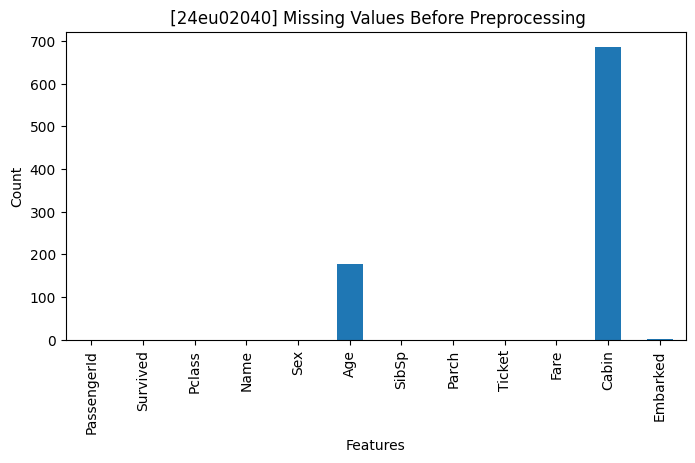

 Missing Values After Preprocessing:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer

# Plot missing values before preprocessing
import matplotlib.pyplot as plt

missing = titanic_df.isnull().sum()

plt.figure(figsize=(8,4))
missing.plot(kind='bar')
plt.title(" [24eu02040] Missing Values Before Preprocessing")
plt.xlabel("Features")
plt.ylabel("Count")
plt.show()

# Fill missing values
age_imputer = SimpleImputer(strategy='median')
titanic_df['Age'] = age_imputer.fit_transform(titanic_df[['Age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
titanic_df['Embarked'] = embarked_imputer.fit_transform(
    titanic_df[['Embarked']]
).ravel()

# Drop Cabin column
titanic_df.drop(columns=['Cabin'], inplace=True)

print(" Missing Values After Preprocessing:\n")
print(titanic_df.isnull().sum())

In [ ]:
# Select numerical features for scaling
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

X = titanic_df[features]

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalization
minmax = MinMaxScaler()
X_normalized = minmax.fit_transform(X)

print("Normalized Range:", X_normalized.min(), "to", X_normalized.max())

# Standardization
standard = StandardScaler()
X_standardized = standard.fit_transform(X)

print("\nStandardized Mean:", round(X_standardized.mean(),4))
print("Standardized Std:", round(X_standardized.std(),4))

Normalized Range: 0.0 to 1.0

Standardized Mean: 0.0
Standardized Std: 1.0


In [ ]:
from sklearn.preprocessing import PowerTransformer

# Create PowerTransformer object
pt = PowerTransformer(method='yeo-johnson')

# Transform Fare column
titanic_df['Fare_Transformed'] = pt.fit_transform(titanic_df[['Fare']])

print(titanic_df[['Fare', 'Fare_Transformed']].head())

      Fare  Fare_Transformed
0   7.2500         -0.878820
1  71.2833          1.336651
2   7.9250         -0.790065
3  53.1000          1.067352
4   8.0500         -0.774439


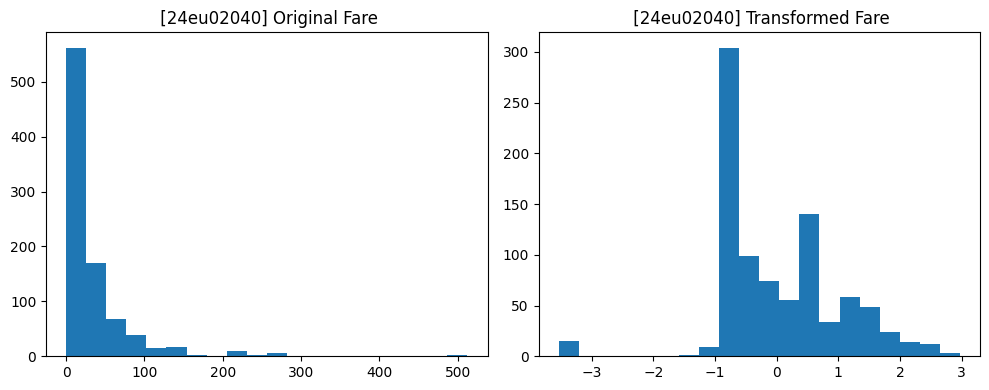

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(titanic_df['Fare'], bins=20)
plt.title(" [24eu02040] Original Fare")

plt.subplot(1,2,2)
plt.hist(titanic_df['Fare_Transformed'], bins=20)
plt.title(" [24eu02040] Transformed Fare")

plt.tight_layout()
plt.show()

In [ ]:
# Save dataset
titanic_df.to_csv("processed_titanic.csv", index=False)

print("Processed Titanic dataset saved successfully.")
print(titanic_df.head())

Processed Titanic dataset saved successfully.
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  Fare_Transformed  
0      0         A/5 21171   7.2500        S         -0.878820  
1      0          PC 17599  71.2833        C          1.336651  
2      0  STON/O2. 3101282   7.9250        S         -0.790065  
3      0      